# Computational Physics: Problem Set 6

## Exercise 1)

### 10.9 The Ising Model

#### a) Total Energy

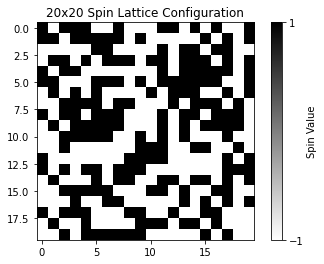

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Markov chain Monte Carlo simulation of the Ising model on the square lattice

#Size: 20 x 20 spins
N=20

#Create randomly oriented spins for high T

lattice=np.random.choice([-1,1], size=(N,N))

#for i in range (N):
    #print(lattice[0][i])

plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.title(f"{N}x{N} Spin Lattice Configuration")
plt.colorbar(ticks=[-1, 1], label='Spin Value')
plt.show()



In [4]:
#Calculate total energy

def energy(N,J):
    
    E_i_sum=0
    
    for i in range(N):
        for j in range(N):
            s_i=lattice[i][j]
            s_1=lattice[(i-1)%N][j]
            s_2=lattice[(i+1)%N][j]
            s_3=lattice[i][(j-1)%N]
            s_4=lattice[i][(j+1)%N]

            E_i_sum+=s_i*(s_1+s_2+s_3+s_4)
    
    E=-J*0.5*E_i_sum
    #print('The total energy is ' f'{E}.')
    
    return E


In [5]:
E_j=energy(20,1)

print(E_j)

40.0


#### b) Metropolis-style Simulation

In [6]:
T=1

#Choose random spin and flip

i = np.random.randint(0, N)
j = np.random.randint(0, N)

selected_spin = lattice[i, j]

lattice[i, j]*=(-1)

#Calculate energy(20,1)

E_k=energy(20,1)

print(E_k)

44.0


In [7]:
#Compute difference to previous result

dE=E_k-E_j

print(dE)
        

4.0


In [8]:
#Decide whether to accept
import random

val=random.random()

if val<np.exp(-dE/T):
    lattice[i, j]*=(1)
    E_j += dE
    
else:
    lattice[i, j]*=(-1)
    
print(E_j)

40.0


#### c) - d) Total Magnetization

In [69]:
import numpy as np

#Parameters
N = 20          
T = 1        
steps = 1000000
J = 1           

#Initialize
lattice = np.random.choice([1, -1], size=(N, N))
mag = np.sum(lattice)
mag_history = np.zeros(steps) #Speed improvement

for step in range(steps):
    #Pick a random site
    i, j = np.random.randint(0, N, 2)
    spin = lattice[i, j]

    #Calculate local energy difference
    #Consider PBCs
    neighbors = lattice[(i+1)%N, j] + lattice[(i-1)%N, j] + \
                lattice[i, (j+1)%N] + lattice[i, (j-1)%N]
    
    dE = 2 * J * spin * neighbors

    #Metropolis Criterion
    accepted = False
    if dE <= 0:
        accepted = True
    elif np.random.random() < np.exp(-dE / T):
        accepted = True

    #Update lattice and magnetization
    if accepted:
        lattice[i, j] *= -1
        mag += 2 * (-spin) # If it was 1, it's now -1 (change of -2)

    mag_history[step] = mag

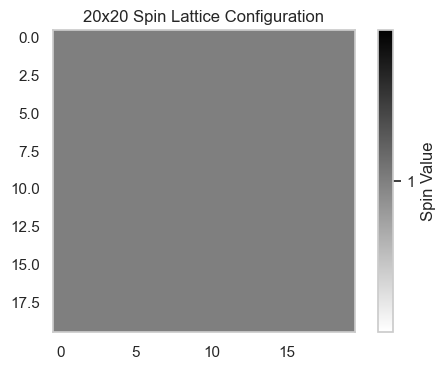

In [71]:
#New lattice
plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.title(f"{N}x{N} Spin Lattice Configuration")
plt.colorbar(ticks=[-1, 1], label='Spin Value')
plt.grid()
plt.show()

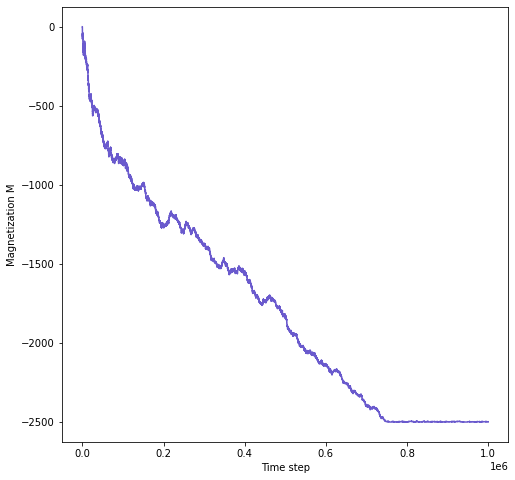

In [27]:
#Plot Magnetization against time
plt.figure(figsize=(4, 4))
plt.plot(mag_history, color='slateblue')
plt.xlabel('Time step')
plt.ylabel('Magnetization M')
plt.show()

Running simulation 1/8...
Running simulation 2/8...
Running simulation 3/8...
Running simulation 4/8...
Running simulation 5/8...
Running simulation 6/8...
Running simulation 7/8...
Running simulation 8/8...


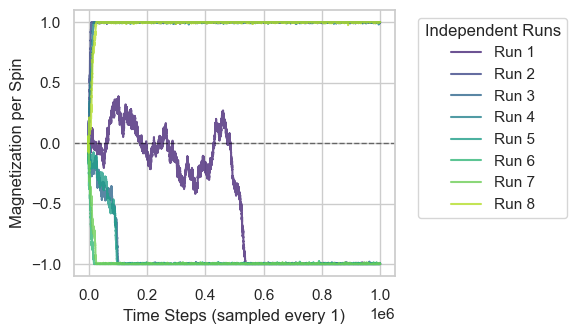

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#PLot multiple runs in one plot

#Style Setup
sns.set_theme(style="whitegrid") #Clean background
plt.rcParams['figure.dpi'] = 100 #Plot quality

#Parameters
N = 20              
T = 1            
steps = 1000000     
num_runs = 8        
subsample = 1

#Colormap (Options: 'viridis', 'rocket', 'mako', 'flare')
palette = sns.color_palette("viridis", n_colors=num_runs)

#Pre-calculated Boltzmann factors (for speed)
weights = {dE: np.exp(-dE/T) for dE in [-8, -4, 0, 4, 8]}

plt.figure(figsize=(6, 3.5))

#Simulation Loop
for run in range(num_runs):
    print(f"Running simulation {run+1}/{num_runs}...")
    
    #Initialize lattice and magnetization
    lattice = np.random.choice([1, -1], size=(N, N))
    mag = np.sum(lattice)
    history = []

    for step in range(steps):
        #Pick random spin
        i, j = np.random.randint(0, N, 2)
        spin = lattice[i, j]

        #Calculate local energy change
        neighbors = (lattice[(i+1)%N, j] + lattice[(i-1)%N, j] + 
                     lattice[i, (j+1)%N] + lattice[i, (j-1)%N])
        dE = 2 * spin * neighbors

        #Metropolis criterion
        if dE <= 0 or np.random.random() < weights[dE]:
            lattice[i, j] *= -1
            mag += 2 * (-spin) # Efficient mag update

        #Subsampling and Normalization
        if step % subsample == 0:
            history.append(mag / (N*N))

    #Plot
    plt.plot(history, color=palette[run], label=f'Run {run+1}', alpha=0.8, lw=1.5)

# Final formatting
plt.axhline(0, color='black', lw=1, ls='--', alpha=0.5) #Zero line
plt.xlabel(f"Time Steps (sampled every {subsample})", fontsize=12)
plt.ylabel("Magnetization per Spin", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Independent Runs")
plt.tight_layout() #Ensures legend doesn't get cut off

plt.show()

#### e) Animation of Spins on the lattice as a function of temperature

In [1]:
from vpython import *
import numpy as np
import random

#Parameters
N = 20
J = 1.0
steps_per_frame = 50 #How many Monte Carlo steps to do before updating screen

#Initialize
#Pick random spin
lattice = np.random.choice([1, -1], size=(N, N))

#Initialize Grid
scene.title = "2D Ising Model\nAdjust T to see Phase Transition"
scene.width = 600
scene.height = 600
scene.center = vector(N/2, N/2, 0) # Center camera

#Store sphere objects in a 2D list
visual_grid = []
color_plus = vec(0.902, 0.902, 0.980)
color_minus = vec(0.576, 0.439, 0.859)

for i in range(N):
    row = []
    for j in range(N):
        #Create sphere at position (i, j)
        #Assign color based on the spin value
        spin_color = color_plus if lattice[i, j] == 1 else color_minus
        
        s = sphere(pos=vector(i, j, 0), radius=0.4, color=spin_color)
        row.append(s)
    visual_grid.append(row)

#Temperature Slider
T = 1
def set_T(s):
    global T
    T = s.value
    t_label.text = f'Temperature T = {T:.2f}'

scene.append_to_caption('\n')
sl = slider(min=0, max=4.0, value=T, length=220, bind=set_T, right=15)
t_label = wtext(text=f'Temperature T = {T:.2f}')

#Simulation Loop
while True:
    rate(30) #Limit animation speed (frames per second)
    
    #Multiple Metropolis steps per frame for speed
    for _ in range(steps_per_frame):
        
        # 1. Pick random site
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        s_i = lattice[i, j]
        
        #Calculate Energy Cost
        up    = lattice[(i-1)%N, j]
        down  = lattice[(i+1)%N, j]
        left  = lattice[i, (j-1)%N]
        right = lattice[i, (j+1)%N]
        
        neighbor_sum = up + down + left + right
        dE = 2 * J * s_i * neighbor_sum
        
        #Metropolis Criterion
        if dE <= 0 or random.random() < np.exp(-dE/T):
            #Flip spin
            lattice[i, j] *= -1
            
            #Visual update
            #Update only the specific sphere that changed
            if lattice[i, j] == 1:
                visual_grid[i][j].color = color_plus
            else:
                visual_grid[i][j].color = color_minus

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

## Exercise 2)

### 10.11 The dimer covering problem
#### a) Simulated Annealing

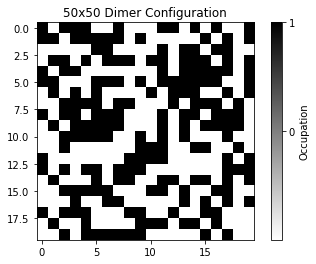

In [4]:
N=50
T=1

#Generate lattice with 0 for empty 1 for occupied

lattice2=np.random.choice([0,1], size=(N,N))

#for i in range (N):
    #print(lattice[0][i])

plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.title(f"{N}x{N} Dimer Configuration")
plt.colorbar(ticks=[0, 1], label='Occupation')
plt.show()

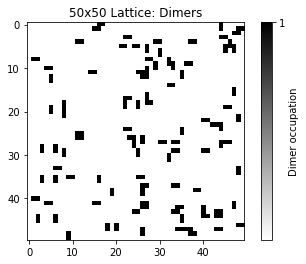

In [5]:
#Now doing that with the condtion that for a site to be 1 at a neighboring site has to be too

import numpy as np
import matplotlib.pyplot as plt

def dimer_lattice(N=50, num_plus_dimers=100):
    rng = np.random.default_rng()
    
    #Initialize all sites to 0
    lattice2 = np.full((N, N), 0, dtype=int)
    
    dimers_placed = 0
    attempts = 0
    while dimers_placed < num_plus_dimers and attempts < 1000:
        attempts += 1
        r, c = rng.integers(0, N, size=2)
        orientation = rng.integers(0, 2) # 0: Horizontal, 1: Vertical
        
        r2, c2 = (r, c + 1) if orientation == 0 else (r + 1, c)
        
        #Check bounds and ensure we aren't overwriting an existing +1 dimer
        if r2 < N and c2 < N:
            if lattice2[r, c] == 0 and lattice2[r2, c2] ==0:
                #Force these two neighbors to be the SAME value (+1)
                lattice2[r, c] = 1
                lattice2[r2, c2] = 1
                dimers_placed += 1
                
    return lattice2

#Generate and plot
N = 50
lattice2 = dimer_lattice(N=N, num_plus_dimers=100)

plt.imshow(lattice2, cmap='binary', interpolation='nearest')
plt.title(f"{N}x{N} Lattice: Dimers")
plt.colorbar(ticks=[-1, 1], label='Dimer occupation')
plt.show()


In [6]:
dimer_lattice()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [7]:
#Calculate total energy

def energy2(lat, N):
    E_i_sum_2 = 0
    for i in range(N):
        for j in range(N):
            s_i = lat[i][j]
            # Only look for dimers if the current site is 1
            if s_i == 1:
                # Periodic boundary conditions for neighbors
                neighbors = [
                    lat[(i-1)%N][j],
                    lat[(i+1)%N][j],
                    lat[i][(j-1)%N],
                    lat[i][(j+1)%N]
                ]
                for val in neighbors:
                    if val == 1:
                        E_i_sum_2 += 1
    
    # Each dimer (pair of 1s) was counted twice (once for each site)
    dimer_quantity = E_i_sum_2 // 2
    return -dimer_quantity



In [8]:
energy2(lattice2, 50)

-125

In [9]:
#Choose two adjacent sites on the lattice at random. Like for spin.

#Random starting site
i = np.random.randint(0, N)
j = np.random.randint(0, N)

#Random neighbor: 0=Right, 1=Left, 2=Down, 3=Up
direction = np.random.randint(0, 4)

if direction == 0:   #Right
    k, l = i, (j + 1) % N
elif direction == 1: #Left
    k, l = i, (j - 1) % N
elif direction == 2: #Down
    k, l = (i + 1) % N, j
else:                #Up
    k, l = (i - 1) % N, j


selected_dimer = [lattice2[i, j], lattice2[k, l]]

site1_val = lattice2[i, j]
site2_val = lattice2[k, l]

print(f"Site 1: ({i}, {j}) Value: {site1_val}")
print(f"Site 2: ({k}, {l}) Value: {site2_val}")

Site 1: (37, 4) Value: 0
Site 2: (38, 4) Value: 0


In [10]:
#If those two sites are currently both empty, place a dimer on them. do +1

E=energy2(lattice2, 50)

if selected_dimer[0]==0 and selected_dimer[1]==0:
    
    selected_dimer[0]+=1
    selected_dimer[1]+=1

    E-=1

#If the two sites are currently occupied by a single dimer, remove the dimer from the lattice with the appropriate probability 
#(which you will have to workout).
#do -1 if P=exp(-1/T)

if selected_dimer[0]==1 and selected_dimer[1]==1:
    val=random.random()

    if val<np.exp(-1/T):
        selected_dimer[0]-=1
        selected_dimer[1]-=1
        E += 1
    
    #Otherwise, do nothing
    else:
        selected_dimer[0]*=1
        selected_dimer[1]*=1
else:
    selected_dimer[0]*=1
    selected_dimer[1]*=1

print(E)

-126


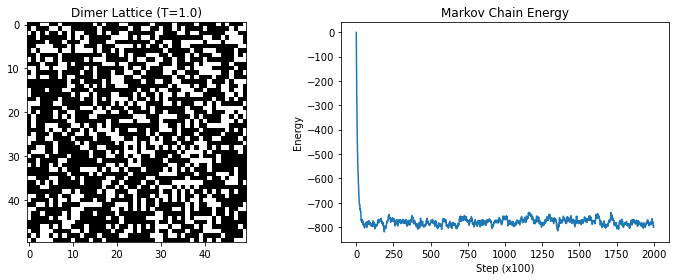

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
N = 50
T = 1.0  #Fixed Temperature
steps = 200000 
lattice2 = np.zeros((N, N), dtype=int)
energy_history = []
E = 0 

rng = np.random.default_rng()

for s in range(steps):
    #Choose two adjacent sites at random
    r, c = rng.integers(0, N, size=2)
    orientation = rng.integers(0, 2) # 0: Horizontal, 1: Vertical
    
    r2, c2 = (r, (c + 1) % N) if orientation == 0 else ((r + 1) % N, c)

    #Metropolis Criterion
    
    #A: Place dimer (Both sites must be empty)
    if lattice2[r, c] == 0 and lattice2[r2, c2] == 0:
        #dE = -1.
        lattice2[r, c] = 1
        lattice2[r2, c2] = 1
        E -= 1

    #B: Remove a dimer (Both sites must be 1)
    elif lattice2[r, c] == 1 and lattice2[r2, c2] == 1:
        #dE = +1. Accept with P = exp(-1/T)
        if rng.random() < np.exp(-1.0 / T):
            lattice2[r, c] = 0
            lattice2[r2, c2] = 0
            E += 1
            
    #Track energy every 100 steps
    if s % 100 == 0:
        energy_history.append(E)

#Final Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(lattice2, cmap='binary', interpolation='nearest')
plt.title(f"Dimer Lattice (T={T})")

plt.subplot(1, 2, 2)
plt.plot(energy_history)
plt.title("Markov Chain Energy")
plt.xlabel("Step (x100)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()


#### b) Animation dimer covering for different cooling protocols

In [12]:
from vpython import *
import numpy as np
import random

#Parameters
N = 50
T0 = 5.0
taus = [10**4, 10**5, 10**6]
steps_per_frame = 100
t_step = 0

#Helper Function for a Simulation Instance
class DimerSim:
    def __init__(self, tau_val, title, pos_x):
        #Create a separate canvas for simulation
        self.canvas = canvas(title=title, width=400, height=400, x=pos_x)
        self.canvas.center = vector(N/2, N/2, 0)
        self.tau = tau_val
        self.lattice = np.zeros((N, N), dtype=int)
        self.visual_grid = []
        self.color_empty = vec(0.2, 0.2, 0.2)
        self.color_dimer = vec(0.5, 0.8, 1.0)
        
        #Build visual grid
        for i in range(N):
            row = []
            for j in range(N):
                s = sphere(canvas=self.canvas, pos=vector(i, j, 0), radius=0.4, color=self.color_empty)
                row.append(s)
            self.visual_grid.append(row)
        
        self.label = wtext(canvas=self.canvas, text=f"T: {T0:.3f} | Tau: {self.tau}")

    def update(self, current_t):
        T = T0 * np.exp(-current_t / self.tau)
        self.label.text = f"T: {T:.4f} | Tau: {self.tau}"
        
        for _ in range(steps_per_frame):
            r, c = np.random.randint(0, N, size=2)
            orientation = np.random.randint(0, 2)
            r2, c2 = (r, (c + 1) % N) if orientation == 0 else ((r + 1) % N, c)
            
            #Dimer Logic
            if self.lattice[r, c] == 0 and self.lattice[r2, c2] == 0:
                self.lattice[r, c], self.lattice[r2, c2] = 1, 1
                self.visual_grid[r][c].color = self.color_dimer
                self.visual_grid[r2][c2].color = self.color_dimer
            elif self.lattice[r, c] == 1 and self.lattice[r2, c2] == 1:
                if random.random() < np.exp(-1.0 / max(T, 1e-10)):
                    self.lattice[r, c], self.lattice[r2, c2] = 0, 0
                    self.visual_grid[r][c].color = self.color_empty
                    self.visual_grid[r2][c2].color = self.color_empty

#Initialize 3 Independent Simulations
sims = [
    DimerSim(taus[0], "Fast Cooling (Tau=10,000)", 0),
    DimerSim(taus[1], "Medium Cooling (Tau=100,000)", 410),
    DimerSim(taus[2], "Slow Annealing (Tau=1,000,000)", 820)
]

#Main Unified Loop
while True:
    rate(60)
    for sim in sims:
        sim.update(t_step)
    t_step += steps_per_frame


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

## Exercise 3)

### Power spectra of random numbers and random walks
#### a) Create a linear congruential random number generator (LCG)

In [13]:
class LCG:
    def __init__(self, seed=1, a=1664525, c=1013904223, m=2**32):
        """
        Initializing LCG with standard 'Numerical Recipes' constants.
        """
        self.state = seed
        self.a = a
        self.c = c
        self.m = m

    def next_int(self):
        """Generating the next random integer."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def next_float(self):
        """Generating a random float between 0 and 1."""
        return self.next_int() / self.m

In [14]:
generator = LCG(seed=42)

print("Random Integers:")
for _ in range(5):
    print(generator.next_int())

print("\nRandom Floats [0, 1):")
for _ in range(5):
    print(round(generator.next_float(), 4))

Random Integers:
1083814273
378494188
2479403867
955863294
1613448261

Random Floats [0, 1):
0.0257
0.4473
0.1185
0.8738
0.9946


#### b) Generate Gaussian random variables

In [20]:
class GaussianGenerator:
    def __init__(self, seed=1, a=1664525, c=1013904223, m=2**32):
        """
        Initializing LCG with standard 'Numerical Recipes' constants.
        """
        self.state = seed
        self.a = a
        self.c = c
        self.m = m
        self.next_val = None

    def next_int(self):
        """Generating the next random integer."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def next_float(self):
        """Generating a random float between 0 and 1."""
        return self.next_int() / self.m
        
    def next_gaussian(self, mean=0, std_dev=1):
            # If we have a stored value from the last pair, return it
            if self.next_val is not None:
                z = self.next_val
                self.next_val = None
                return mean + z * std_dev
    # Otherwise, generate a new pair
            u1 = self.next_float()
            u2 = self.next_float()
    
            # Apply Box-Muller
            mag = np.sqrt(-2.0 * np.log(u1))
            z0 = mag * np.cos(2.0 * np.pi * u2)
            z1 = mag * np.sin(2.0 * np.pi * u2)
    
            self.next_val = z1 # Store the second one for next time
            return mean + z0 * std_dev

In [22]:
gen = GaussianGenerator(seed=42)
samples = [gen.next_gaussian() for _ in range(5)]
print("Gaussian Samples:", [round(s, 4) for s in samples])

Gaussian Samples: [1.4115, 0.8726, 0.1799, 1.0327, 1.3812]


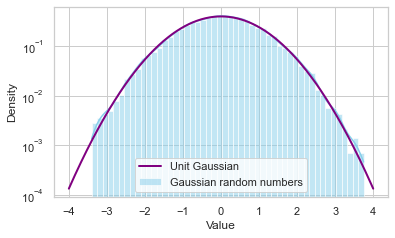

In [63]:
import seaborn as sns

#Generate 10,000 samples
gen = GaussianGenerator(seed=42)
samples = [gen.next_gaussian() for _ in range(10000)]

#Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 3.5))

#Histogram
#'stat="density"' scales the y-axis so the area of the bars equals 1
sns.histplot(samples, bins=50, kde=True, color="skyblue", stat="density", label="Gaussian random numbers")

#Overlay Theoretical Normal Curve
x = np.linspace(-4, 4, 1000)
pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
plt.plot(x, pdf, color="purple", lw=2, label="Unit Gaussian")

# Formatting
plt.xlabel("Value")
plt.yscale('log')
plt.legend()
plt.show()

#### c) Power spectrum of random numbers

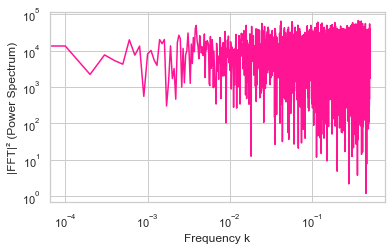

In [60]:
#Fourier transform
FFT_samples = np.fft.fft(samples)

freq = np.fft.fftfreq(len(samples), d=1) #set equally spaced freq axis
power = np.abs(FFT_samples)**2 #compute mag^2

mask = freq >= 0 #for plotting only pos freqs

plt.figure(figsize=(6,3.5))
plt.plot(freq[mask], power[mask], color='deeppink')
plt.xlabel('Frequency k')
plt.ylabel('|FFT|² (Power Spectrum)')
#plt.xlim(0,0.01)
#plt.ylim(0,0.25*10**10)
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

#### d) Generate a random walk

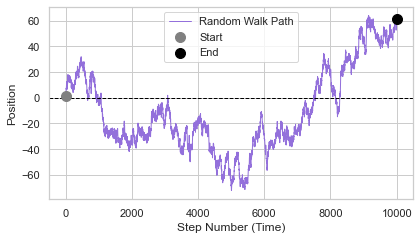

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assuming the GaussianGenerator class is defined above ---

# 1. Generate the steps
gen = GaussianGenerator(seed=42)
n_steps = 10000
steps = [gen.next_gaussian(mean=0, std_dev=1) for _ in range(n_steps)]

# 2. Calculate the Random Walk (Cumulative Sum)
# Position = sum of all previous steps
walk = np.cumsum(steps)

# 3. Plotting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 3.5))

plt.plot(walk, color='mediumpurple', lw=1, label='Random Walk Path')

# Mark the start and end points
plt.scatter(0, walk[0], color='gray', s=100, label='Start', zorder=5)
plt.scatter(n_steps, walk[-1], color='black', s=100, label='End', zorder=5)

plt.xlabel("Step Number (Time)")
plt.ylabel("Position")
plt.axhline(0, color='black', lw=1, ls='--') # Baseline
plt.legend()
plt.tight_layout()
plt.show()

#### e) Power spectrum of a random walk

/var/folders/ch/6zd8rw0j62lg36l1m378jf_m0000gp/T/ipykernel_6319/2657467900.py:11: RuntimeWarning: divide by zero encountered in power
  reference_line = C * (freq2[mask]**-2)


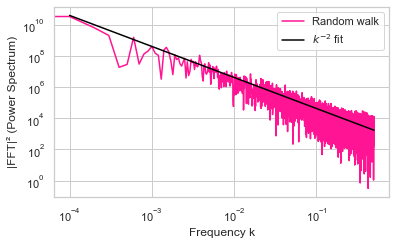

In [61]:
FFT_walk = np.fft.fft(walk)

freq2 = np.fft.fftfreq(len(walk), d=1) #set equally spaced freq axis
power2 = np.abs(FFT_walk)**2 #compute mag^2

mask = freq >= 0 #for plotting only pos freqs


anchor_idx = 10
C = power2[anchor_idx] * (freq2[anchor_idx]**2) 
reference_line = C * (freq2[mask]**-2)


plt.figure(figsize=(6,3.5))
plt.plot(freq2[mask], power2[mask], color='deeppink', label='Random walk')
plt.loglog(freq2[mask], reference_line, color='black', label=r'$k^{-2}$ fit')
plt.xlabel('Frequency k')
plt.ylabel('|FFT|² (Power Spectrum)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()